In [104]:
import gc
import warnings
from pathlib import Path
import optuna

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

In [105]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df = pd.concat([df_train, df_test], axis=0,ignore_index=True)

In [106]:
df_test[:-10]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4262,9243_01,Europa,False,E/596/P,TRAPPIST-1e,35.0,False,0.0,4813.0,0.0,142.0,523.0,Sollum Pumpeshaft
4263,9245_01,Earth,False,F/1791/S,TRAPPIST-1e,20.0,False,1272.0,3.0,543.0,0.0,0.0,Eriana Jenkinnedy
4264,9249_01,Earth,False,G/1492/S,TRAPPIST-1e,21.0,False,147.0,603.0,20.0,0.0,0.0,Hilip Lambles
4265,9255_01,Mars,False,F/1794/S,TRAPPIST-1e,32.0,False,46.0,3.0,1258.0,0.0,0.0,Skies Bota


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12682 non-null  str    
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12696 non-null  str    
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  str    
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(3), str(5)
memory usage: 1.9+ MB


In [108]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [109]:
import pandas as pd

null_percentages = []

for col in df.columns:
    percentage = (df[col].isna().sum() / len(df)) * 100
    null_percentages.append([col, percentage])

null_df = pd.DataFrame(null_percentages, columns=["Column", "Null_Percentage"])

print(null_df)

          Column  Null_Percentage
0    PassengerId         0.000000
1     HomePlanet         2.220509
2      CryoSleep         2.390131
3          Cabin         2.305320
4    Destination         2.112567
5            Age         2.081727
6            VIP         2.282190
7    RoomService         2.027756
8      FoodCourt         2.228219
9   ShoppingMall         2.359291
10           Spa         2.189668
11        VRDeck         2.066307
12          Name         2.266769
13   Transported        32.976099


In [110]:
df.HomePlanet.unique()

<ArrowStringArray>
['Europa', 'Earth', 'Mars', nan]
Length: 4, dtype: str

<Axes: xlabel='HomePlanet', ylabel='count'>

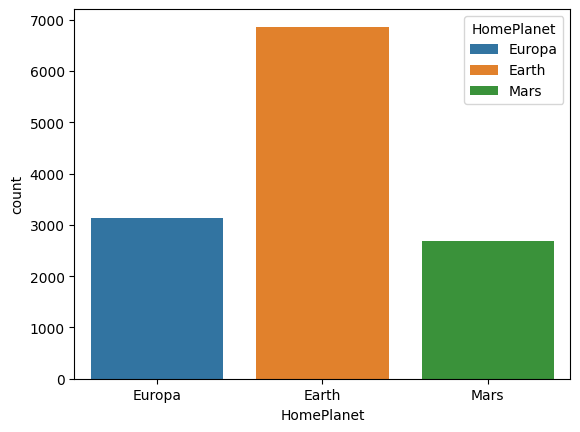

In [111]:
sns.countplot(
    x='HomePlanet',
    data=df,
    hue='HomePlanet'
)

<Axes: xlabel='Destination', ylabel='count'>

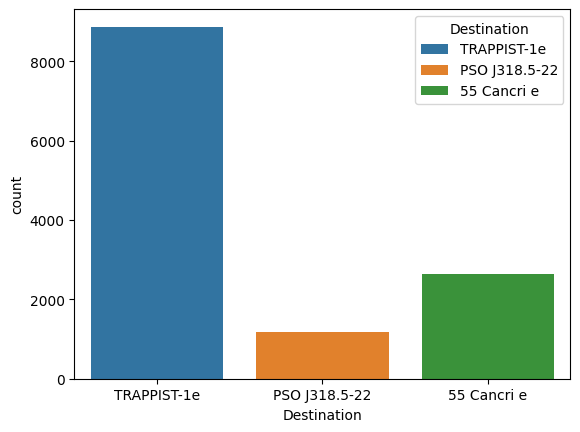

In [112]:
sns.countplot(
    x='Destination',
    data=df,
    hue='Destination'
)

In [113]:
df.nunique()

PassengerId     12970
HomePlanet          3
CryoSleep           2
Cabin            9825
Destination         3
Age                80
VIP                 2
RoomService      1578
FoodCourt        1953
ShoppingMall     1367
Spa              1679
VRDeck           1642
Name            12629
Transported         2
dtype: int64

In [114]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [115]:
df['Cabin']

0           B/0/P
1           F/0/S
2           A/0/S
3           A/0/S
4           F/1/S
           ...   
12965    G/1496/S
12966     G/160/P
12967     D/296/P
12968     D/297/P
12969    G/1498/S
Name: Cabin, Length: 12970, dtype: str

In [116]:
drop_cols = ['Cabin','Age']

# Splitting the stuff for Cabin and droping the columns

In [117]:
df[['deck','num','side']] = df['Cabin'].str.split('/', expand=True)
df['num'] = df['num'].astype('int')

<Axes: xlabel='deck', ylabel='count'>

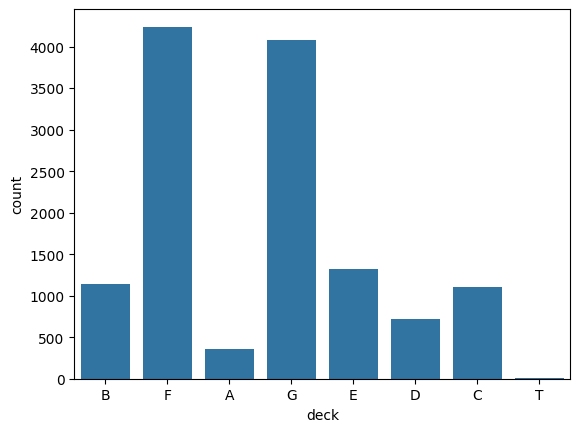

In [118]:
sns.countplot(
    x='deck',
    data=df
)

In [119]:
df['Age'].describe()

count    12700.000000
mean        28.771969
std         14.387261
min          0.000000
25%         19.000000
50%         27.000000
75%         38.000000
max         79.000000
Name: Age, dtype: float64

# Binning by age group

In [120]:
bins = [0, 12, 19, 35, 50, 65, 80]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=False)

# Converting Boolean Columns in 0 and 1

In [121]:
df['Transported'] = np.where(df['Transported'] == True,1,0)
df['VIP'] = np.where(df['VIP'] == True,1,0)
df['VIP'] = np.where(df['VIP'] == True,1,0)
df['CryoSleep'] = np.where(df['CryoSleep'] == True,1,0)

# getting the categorical columns

In [122]:
cat_cols=df.select_dtypes(include='object').columns.tolist()
num_cols=df.select_dtypes(include='number').columns.tolist()

# Total Spendings by each Passenger

In [123]:
spending_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

df['Total_Spendings'] = df[spending_cols].fillna(0).sum(axis=1)

# Getting the Cat and Numeric Columns

In [124]:
print(cat_cols)
print(num_cols)

['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name', 'deck', 'side']
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'num', 'Age_Group']


In [125]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,deck,num,side,Age_Group,Total_Spendings
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0,B,0,P,3.0,0.0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1,F,0,S,2.0,736.0
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,A,0,S,4.0,10383.0
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,A,0,S,2.0,5176.0
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1,F,1,S,1.0,1091.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,1,G/1496/S,TRAPPIST-1e,34.0,0,0.0,0.0,0.0,0.0,0.0,Jeron Peter,0,G,1496,S,2.0,0.0
12966,9269_01,Earth,0,G/160/P,TRAPPIST-1e,42.0,0,0.0,847.0,17.0,10.0,144.0,Matty Scheron,0,G,160,P,3.0,1018.0
12967,9271_01,Mars,1,D/296/P,55 Cancri e,NaN,0,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,0,D,296,P,NaN,0.0
12968,9273_01,Europa,0,D/297/P,NaN,NaN,0,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,0,D,297,P,NaN,3203.0


# Normalizing Total_Spendings column

In [132]:
df['Total_Spendings'] = (df['Total_Spendings'] - df['Total_Spendings'].mean()) / df['Total_Spendings'].std()

# Spread of money by Vip People and Non VIP

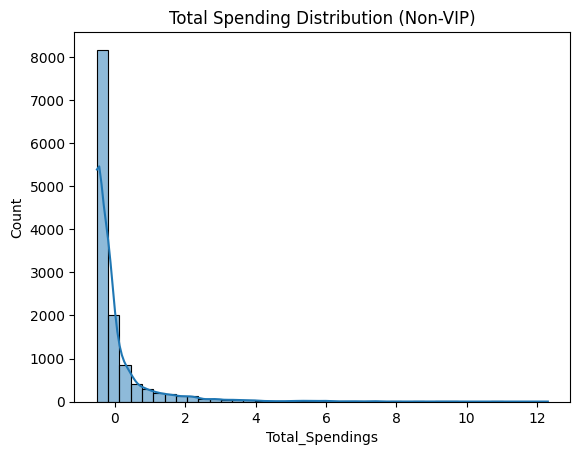

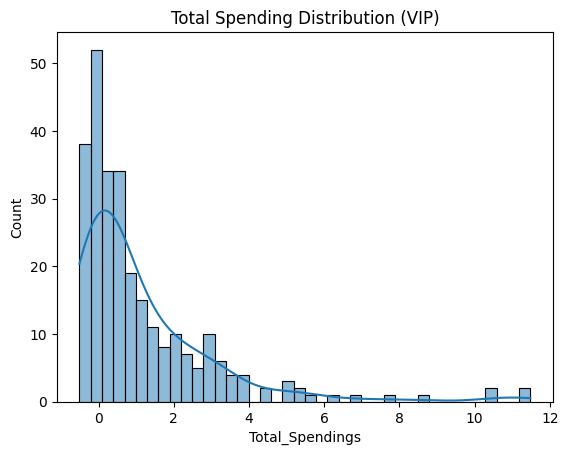

In [134]:
sns.histplot(
    x='Total_Spendings',
    data=df[df['VIP'] == 0],
    bins=40,
    kde=True
)
plt.title("Total Spending Distribution (Non-VIP)")
plt.show()

sns.histplot(
    x='Total_Spendings',
    data=df[df['VIP'] == 1],
    bins=40,
    kde=True
)
plt.title("Total Spending Distribution (VIP)")
plt.show()

In [135]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,deck,num,side,Age_Group,Total_Spendings
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0,B,0,P,3.0,-0.510521
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1,F,0,S,2.0,-0.248354
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,A,0,S,4.0,3.187959
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,A,0,S,2.0,1.333198
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1,F,1,S,1.0,-0.121901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,1,G/1496/S,TRAPPIST-1e,34.0,0,0.0,0.0,0.0,0.0,0.0,Jeron Peter,0,G,1496,S,2.0,-0.510521
12966,9269_01,Earth,0,G/160/P,TRAPPIST-1e,42.0,0,0.0,847.0,17.0,10.0,144.0,Matty Scheron,0,G,160,P,3.0,-0.147904
12967,9271_01,Mars,1,D/296/P,55 Cancri e,NaN,0,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,0,D,296,P,NaN,-0.510521
12968,9273_01,Europa,0,D/297/P,NaN,NaN,0,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,0,D,297,P,NaN,0.630405


<Axes: xlabel='Transported', ylabel='count'>

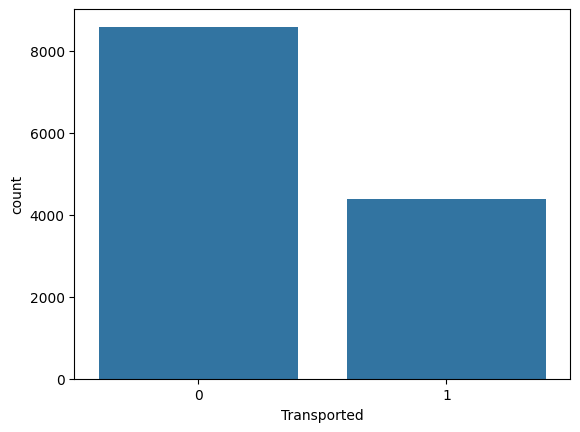

In [137]:
sns.countplot(
    x='Transported',
    data=df
)

In [140]:
df.corr(numeric_only=True)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,num,Age_Group,Total_Spendings
CryoSleep,1.000000,-0.064569,-0.076891,-0.254352,-0.210556,-0.218003,-0.201455,-0.192238,0.319534,-0.039509,-0.078025,-0.377273
Age,-0.064569,1.000000,0.081004,0.067300,0.124447,0.034959,0.118992,0.101441,-0.050775,-0.135360,0.948973,0.179890
VIP,-0.076891,0.081004,1.000000,0.059829,0.124197,0.024500,0.081310,0.111594,-0.018345,-0.090311,0.071638,0.165179
RoomService,-0.254352,0.067300,0.059829,1.000000,-0.020146,0.057402,0.008936,-0.023847,-0.176328,-0.009964,0.060919,0.225418
FoodCourt,-0.210556,0.124447,0.124197,-0.020146,1.000000,-0.001589,0.228990,0.244279,0.036364,-0.177231,0.116853,0.747820
ShoppingMall,-0.218003,0.034959,0.024500,0.057402,-0.001589,1.000000,0.010504,0.004485,0.005941,-0.008207,0.036699,0.229435
Spa,-0.201455,0.118992,0.081310,0.008936,0.228990,0.010504,1.000000,0.149874,-0.156006,-0.130651,0.110462,0.593120
VRDeck,-0.192238,0.101441,0.111594,-0.023847,0.244279,0.004485,0.149874,1.000000,-0.143561,-0.135304,0.097066,0.605014
Transported,0.319534,-0.050775,-0.018345,-0.176328,0.036364,0.005941,-0.156006,-0.143561,1.000000,-0.035543,-0.045392,-0.139225
num,-0.039509,-0.135360,-0.090311,-0.009964,-0.177231,-0.008207,-0.130651,-0.135304,-0.035543,1.000000,-0.118938,-0.208896


<Axes: >

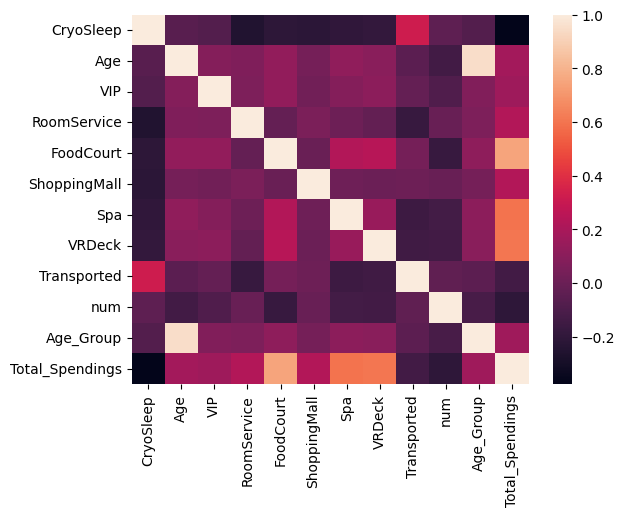

In [139]:
sns.heatmap(df.corr(numeric_only=True))